# Experiment 2 — MNIST Simulated Domain Shift

**Paper:** *Transferability Loss for Safe Model Selection under Domain Shift* (ICLR 2026)

**Dataset:** MNIST handwritten digits (30 % subsample). A synthetic target domain is created by injecting Gaussian noise ($\mu=150$, $\sigma=10$) into pixel columns 100–299, simulating a structured covariate shift between the clean source and noisy target.

**Objective:** Evaluate TR-LOSS as a model-selection criterion for classification under domain shift, where target labels are unavailable at selection time.

**Protocol:**
1. Encode digit labels via one-hot encoding and fit KDA-PLS models (RBF kernel) over a grid of latent components (`n_comp`), regularization strength (`λ`), and kernel bandwidth (`γ`).
2. Compute the following quantities per model:
   - **ACCV\_S** — source validation accuracy
   - **τ\_ACC** (TR\_LOSS) — agreement between paired target-domain predictions (accuracy between source-anchored and adapted hypotheses)
   - **ACCV\_T** — target validation accuracy (oracle only)
   - **ACCP\_T** — target test accuracy (final evaluation)
   - **MMD** — maximum mean discrepancy between source and target latent scores
3. Select models by maximising the composite criterion $J_{\mathrm{cls}} = \mathrm{ACC}_S + \tau_{\mathrm{ACC}}$ (Eq. 11) and compare against source-only, MMD-based, and oracle baselines.

## Load modules

In [1]:

import sys
sys.path.append("../../../methods/")

from kdaPLS.kdapls import KDAPLSRegression
from trloss import transferability_loss, selection_criterion
from metrics.mmd import mmd_rbf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtply
import plotly.express as px
import plotly.graph_objects as go
import scipy.io as sp_io


from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder


## Load & generate data

- Source

c:\Users\nikzad\AppData\Local\miniconda3\envs\trloss2026\Lib\site-packages\sklearn\datasets\_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


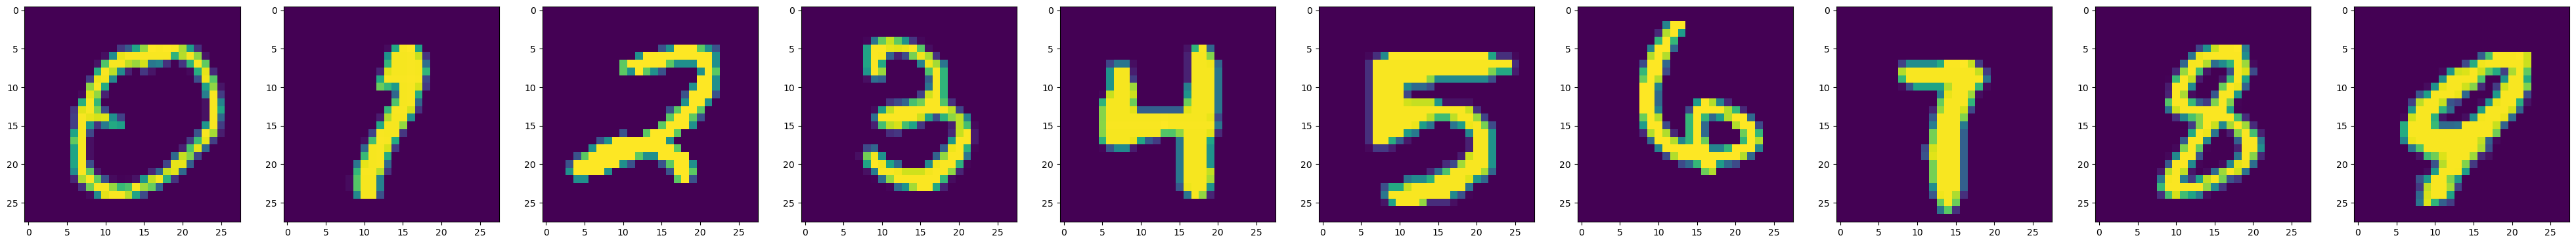

In [2]:
# Load the MNIST dataset
mnist = fetch_openml('mnist_784')
X_minst_all_orig = np.array(mnist.data)
y_minst_all_orig = np.array(mnist.target.astype(np.uint8))
samples_ids = np.random.choice(X_minst_all_orig.shape[0], int(X_minst_all_orig.shape[0]*0.3), replace = False)
X_minst_all = X_minst_all_orig[samples_ids,:]
y_minst_all = y_minst_all_orig[samples_ids]

X = X_minst_all.copy()
y = y_minst_all.copy()

fig, ax = plt.subplots(1,10,figsize=(50,5))

for k,yi in enumerate(np.unique(y)):

    x = X[np.where(y==yi)[0][0]].T.reshape(28,28)

    ax[k].imshow(x)
    
plt.show()

le = OneHotEncoder(categories = "auto")
le.fit(y_minst_all.reshape(-1, 1))
y_minst_encode = le.transform(y_minst_all.reshape(-1, 1)).toarray()

- Simulate target

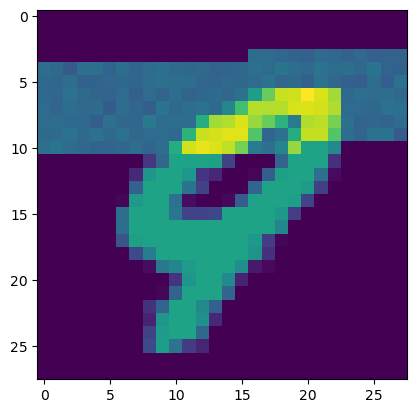

In [3]:
X_target = X_minst_all.copy()
pix_sel_2 = np.arange(100,300)
X_target[:,pix_sel_2] = X_target[:,pix_sel_2] + np.random.normal(loc=150, scale = 10, size=X_target[:,pix_sel_2].shape) 

x = X_target[0,:].T.reshape(28,28)

plt.imshow(x)
plt.show()

In [4]:
# Reduce sample size because of computational effort
s_ids = np.random.choice(X_minst_all.shape[0], int(X_minst_all.shape[0]*0.5), replace = False)
t_ids = [i for i in range(X_minst_all.shape[0]) if i not in s_ids]
Xs_all = X_minst_all[s_ids,:]
ys_all = y_minst_encode[s_ids,:]
Xt_all = X_target[t_ids,:]
yt_all = y_minst_encode[t_ids]

data_dict = {}

data_dict["X_minst"] = Xs_all
data_dict["Y_minst"] = ys_all

data_dict["X_sminst"] = Xt_all
data_dict["Y_sminst"] = yt_all

domains = ["minst","sminst"]

print(Xs_all.shape)
print(Xt_all.shape[0])

(10500, 784)
10500


## Generate adaptations

In [5]:
# Hyperparameters
kernel_type = "rbf"                        # Kernel
gamma_list = np.logspace(-10,0,5)          # Kernel width
n_comp_list = [i for i in range(18,23)]    # Number of LVs
lambda_list = np.logspace(0,10,5)          # Regularization parameter
lambda_list[0] = 0                  

In [6]:
model_results = {}
k = 0

for source_name in domains:
    domains_source = [re for re in domains if re!=source_name]
    for target_name in domains_source:
        print(source_name, target_name)

        Xs_all = data_dict[f"X_{source_name}"]
        Xt_all = data_dict[f"X_{target_name}"]
        ys_all = data_dict[f"Y_{source_name}"]
        yt_all = data_dict[f"Y_{target_name}"]
        


        # Splitting

        Xs, Xs_val_test, ys, ys_val_test = train_test_split(Xs_all, ys_all, test_size=0.9, random_state=42245368)
        Xs_val, Xs_test, ys_val, ys_test = train_test_split(Xs_val_test, ys_val_test, test_size=0.9, random_state=42245368)
        Xt, Xt_val_test, yt, yt_val_test = train_test_split(Xt_all, yt_all, test_size=0.9, random_state=42245368)
        Xt_val, Xt_test, yt_val, yt_test = train_test_split(Xt_val_test, yt_val_test, test_size=0.9, random_state=42245368)


        
        
        for n_comp in n_comp_list:    
            print(n_comp)#,lambda_,gamma)
            for lambda_ in lambda_list:
                for gamma in gamma_list:

                    try:

                        # print(n_comp,lambda_,gamma)
                        kdict = {"type":"rbf", "gamma":gamma}          
                        # Model
                        kdapls_model = KDAPLSRegression(xs = Xs, xt = Xt, n_components = n_comp, kdict = kdict, l=[lambda_], target_domain = 0)
                        kdapls_model.fit(Xs,ys)
                        # Validation and test prediction
                        yt_val_pred_all = kdapls_model.predict_all(Xt_val)
                        yt_val_pred_all[0] = np.argmax(yt_val_pred_all[0], axis = 1)
                        yt_val_pred_all[1] = np.argmax(yt_val_pred_all[1], axis = 1)
                        ys_val_pred = np.argmax(kdapls_model.predict(Xs_val), axis = 1)
                        yt_test_pred = np.argmax(kdapls_model.predict(Xt_test), axis = 1)
                        # Other distance metrics                
                        ns = Xs.shape[0]
                        nt = Xt.shape[0]
                        mmd = mmd_rbf(kdapls_model.x_scores_st_[:ns,:],kdapls_model.x_scores_st_[ns:,:])
                        # Performance metrics

                        tr_loss = transferability_loss(yt_val_pred_all[0], yt_val_pred_all[1], task="classification")
                        accv = accuracy_score(np.argmax(ys_val,axis=1), ys_val_pred)

                        accv_t = accuracy_score(np.argmax(yt_val,axis=1), yt_val_pred_all[0])

                        accp_t = accuracy_score(np.argmax(yt_test,axis=1), yt_test_pred)





                        model_results[k] = {"TR_LOSS":tr_loss,
                                         "ACCV_S":accv,                                       
                                        "ACCV_T":accv_t,                                        
                                          "ACCP_T":accp_t,                                         
                                          "n_comp":n_comp,
                                          "lambda_":lambda_ ,    
                                        "Source":source_name,
                                        "Target":target_name,
                                        
                                        "MMD":mmd


                                                             }

                    except ValueError:

                        model_results[k] = {"TR_LOSS":None,
                                                 "ACCV_S":None,                                               
                                                "ACCV_T":None,                                                 
                                                  "ACCP_T":None,                                                 
                                                  "n_comp":n_comp,
                                                  "lambda_":lambda_ ,    
                                                "Source":source_name,
                                                "Target":target_name,
                                                "MMD": None
                                                                     }


                    k += 1


minst sminst
18
19
20
21
22
sminst minst
18
19
20
21
22


## Model selection

In [7]:
# We are interested only in the transfer from original to simulated noisy
model_results_pd = pd.DataFrame.from_dict(model_results, orient="index")
model_results_pd = model_results_pd.loc[model_results_pd["Source"]=="minst"].copy()
model_results_pd["domains"] = model_results_pd.apply(lambda x: x["Source"]+"->"+x["Target"], axis = 1)
model_results_pd["model_id"] = np.arange(1, model_results_pd.shape[0]+1)
model_metrics_pd_melt = pd.melt(model_results_pd.loc[:, ["model_id","domains","ACCV_S","MMD","TR_LOSS","ACCV_T","ACCP_T"]], id_vars = ["model_id","domains","ACCV_S","ACCP_T"], var_name = "measure_alignment")

model_metrics_pd_melt['measure_alignment'] = model_metrics_pd_melt['measure_alignment'].replace('TR_LOSS', 'τ<sub>ACC</sub>')

# Compute selection criteria on the filtered (Source==minst) data
mr = model_results_pd.loc[model_results_pd["Source"] == "minst"].dropna().copy()
# Eq. 11: J_cls = ACC_S + τ_ACC  →  maximize
mr["ACCV_S + TR_LOSS"] = selection_criterion(mr["ACCV_S"], mr["TR_LOSS"], task="classification")

best_trloss = mr.loc[mr["ACCV_S + TR_LOSS"].idxmax()]
best_oracle = mr.loc[mr["ACCP_T"].idxmax()]

fig = px.scatter(model_metrics_pd_melt, x = "value", y = "ACCV_S", color = "ACCP_T", 
                 hover_data=["model_id"],
                 facet_col = "measure_alignment", 
                 category_orders={"measure_alignment": ["MMD", "τ<sub>ACC</sub>", "ACCV_T"]},
                 color_continuous_scale=px.colors.sequential.Viridis,
                )
fig.update_xaxes(matches=None)
fig.update_traces(marker=dict(size=12, opacity=0.4))
fig.update_layout(width = 1000, height = 300, font_size = 18,                     
                  legend=dict(
        yanchor="top", y=0.5,
        xanchor="left", x=0.35,
        bgcolor="rgba(255,255,255,0.8)",
        font=dict(size=11)))

# Overlay selected (red cross) and oracle (blue square) on the τ_ACC panel only (col 2)
fig.add_trace(
    go.Scatter(x=[best_trloss["TR_LOSS"]], y=[best_trloss["ACCV_S"]],
               mode="markers",
               marker=dict(symbol="cross", size=14, color="red", opacity=1.0, line=dict(width=2, color="darkred")),
               name="Selected (τ)", legendgroup="selected", showlegend=True,
               hovertemplate=(f"n_comp={int(best_trloss['n_comp'])}, λ={best_trloss['lambda_']:.2g}<br>"
                              f"ACCP_T={best_trloss['ACCP_T']:.3f}<extra></extra>")),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(x=[best_oracle["TR_LOSS"]], y=[best_oracle["ACCV_S"]],
               mode="markers",
               marker=dict(symbol="square", size=12, color="blue", opacity=1.0, line=dict(width=1.5, color="black")),
               name="Oracle (best ACCP<sub>T</sub>)", legendgroup="oracle", showlegend=True,
               hovertemplate=(f"n_comp={int(best_oracle['n_comp'])}, λ={best_oracle['lambda_']:.2g}<br>"
                              f"ACCP_T={best_oracle['ACCP_T']:.3f}<extra></extra>")),
    row=1, col=2
)

# Update facet titles: replace "measure_alignment=X" with "value: X"
for annotation in fig.layout.annotations:
    if "measure_alignment=" in annotation.text:
        label = annotation.text.replace("measure_alignment=", "")
        annotation.text = f"value: {label}"

fig.show()


# Final model

In [8]:
# Re-create full results (cell 13 filters to Source=="minst" only)
model_results_pd = pd.DataFrame.from_dict(model_results, orient="index")

# TR-LOSS criterion (Eq. 11 from paper): J_cls = ACC_S + τ_ACC  →  maximize
model_results_pd["ACCV_S + TR_LOSS"] = selection_criterion(
    model_results_pd["ACCV_S"], model_results_pd["TR_LOSS"], task="classification"
)

# MMD criterion: ACC_S should be maximized, MMD minimized
# Normalize per source-target pair since MMD is in different units
accv_mmd_criterion = pd.Series(dtype=float, index=model_results_pd.index)
for sn in domains:
    for tn in [d for d in domains if d != sn]:
        mask = (model_results_pd["Source"] == sn) & (model_results_pd["Target"] == tn)
        subset = model_results_pd.loc[mask].dropna()
        if subset.empty:
            continue
        mmd_max = subset["MMD"].max()
        accv_max = subset["ACCV_S"].max()
        # Normalize to [0,1]: higher is better for ACC, invert MMD (lower is better)
        accv_norm = subset["ACCV_S"] / accv_max if accv_max > 0 else subset["ACCV_S"]
        mmd_norm = subset["MMD"] / mmd_max if mmd_max > 0 else subset["MMD"]
        accv_mmd_criterion.loc[subset.index] = accv_norm + (1 - mmd_norm)

model_results_pd["ACCV_S + MMD"] = accv_mmd_criterion

final_models_dict = {}
kk = 0
for source_name in domains:
    domains_source = [re for re in domains if re!=source_name]
    for target_name in domains_source:
        filter_domains = ((model_results_pd["Source"] == source_name) & (model_results_pd["Target"] == target_name))        
        model_result_st = model_results_pd.loc[filter_domains].dropna()  
        final_models_dict[kk] = {
                        "Source":source_name,
                        "Target":target_name,
                        # ACCV_S only: maximize source accuracy
                        "ACCV_S": model_result_st.sort_values("ACCV_S").iloc[-1]["ACCP_T"],   
                        # ACCV_S + MMD: maximize combined criterion
                        "ACCV_S + MMD": model_result_st.sort_values("ACCV_S + MMD").iloc[-1]["ACCP_T"],
                        # ACCV_S + TR_LOSS: maximize combined criterion (Eq. 11)
                        "ACCV_S + TR_LOSS": model_result_st.sort_values("ACCV_S + TR_LOSS").iloc[-1]["ACCP_T"],
                        # Oracle: maximize target validation accuracy
                        "ACCV_T": model_result_st.sort_values("ACCV_T").iloc[-1]["ACCP_T"],}

        kk += 1
        
final_models_pd = pd.DataFrame.from_dict(final_models_dict, orient="index")
print(final_models_pd.to_latex(index=False,float_format="{:.2f}".format))


\begin{tabular}{llrrrr}
\toprule
Source & Target & ACCV_S & ACCV_S + MMD & ACCV_S + TR_LOSS & ACCV_T \\
\midrule
minst & sminst & 0.66 & 0.82 & 0.82 & 0.82 \\
sminst & minst & 0.63 & 0.80 & 0.80 & 0.79 \\
\bottomrule
\end{tabular}

